# Experiment 5: Decision Tree vs Random Forest

Breast cancer classification, tuning both models with 5-fold CV.

In [1]:
%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings("ignore")
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, GridSearchCV)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix,
                              ConfusionMatrixDisplay)

RNG = 42
sns.set_style("whitegrid")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 15
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['legend.title_fontsize'] = 15
plt.rcParams['axes.labelweight'] = 'bold'

## Load the data

In [3]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["diagnosis"] = data.target
df["diagnosis_label"] = df["diagnosis"].map({0: "Malignant", 1: "Benign"})

print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Class distribution:\n", df["diagnosis_label"].value_counts())

X = df[list(data.feature_names)].values
y = df["diagnosis"].values
feature_names = list(data.feature_names)

Dataset shape: (569, 32)
Missing values: 0
Class distribution:
 diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64


## EDA

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


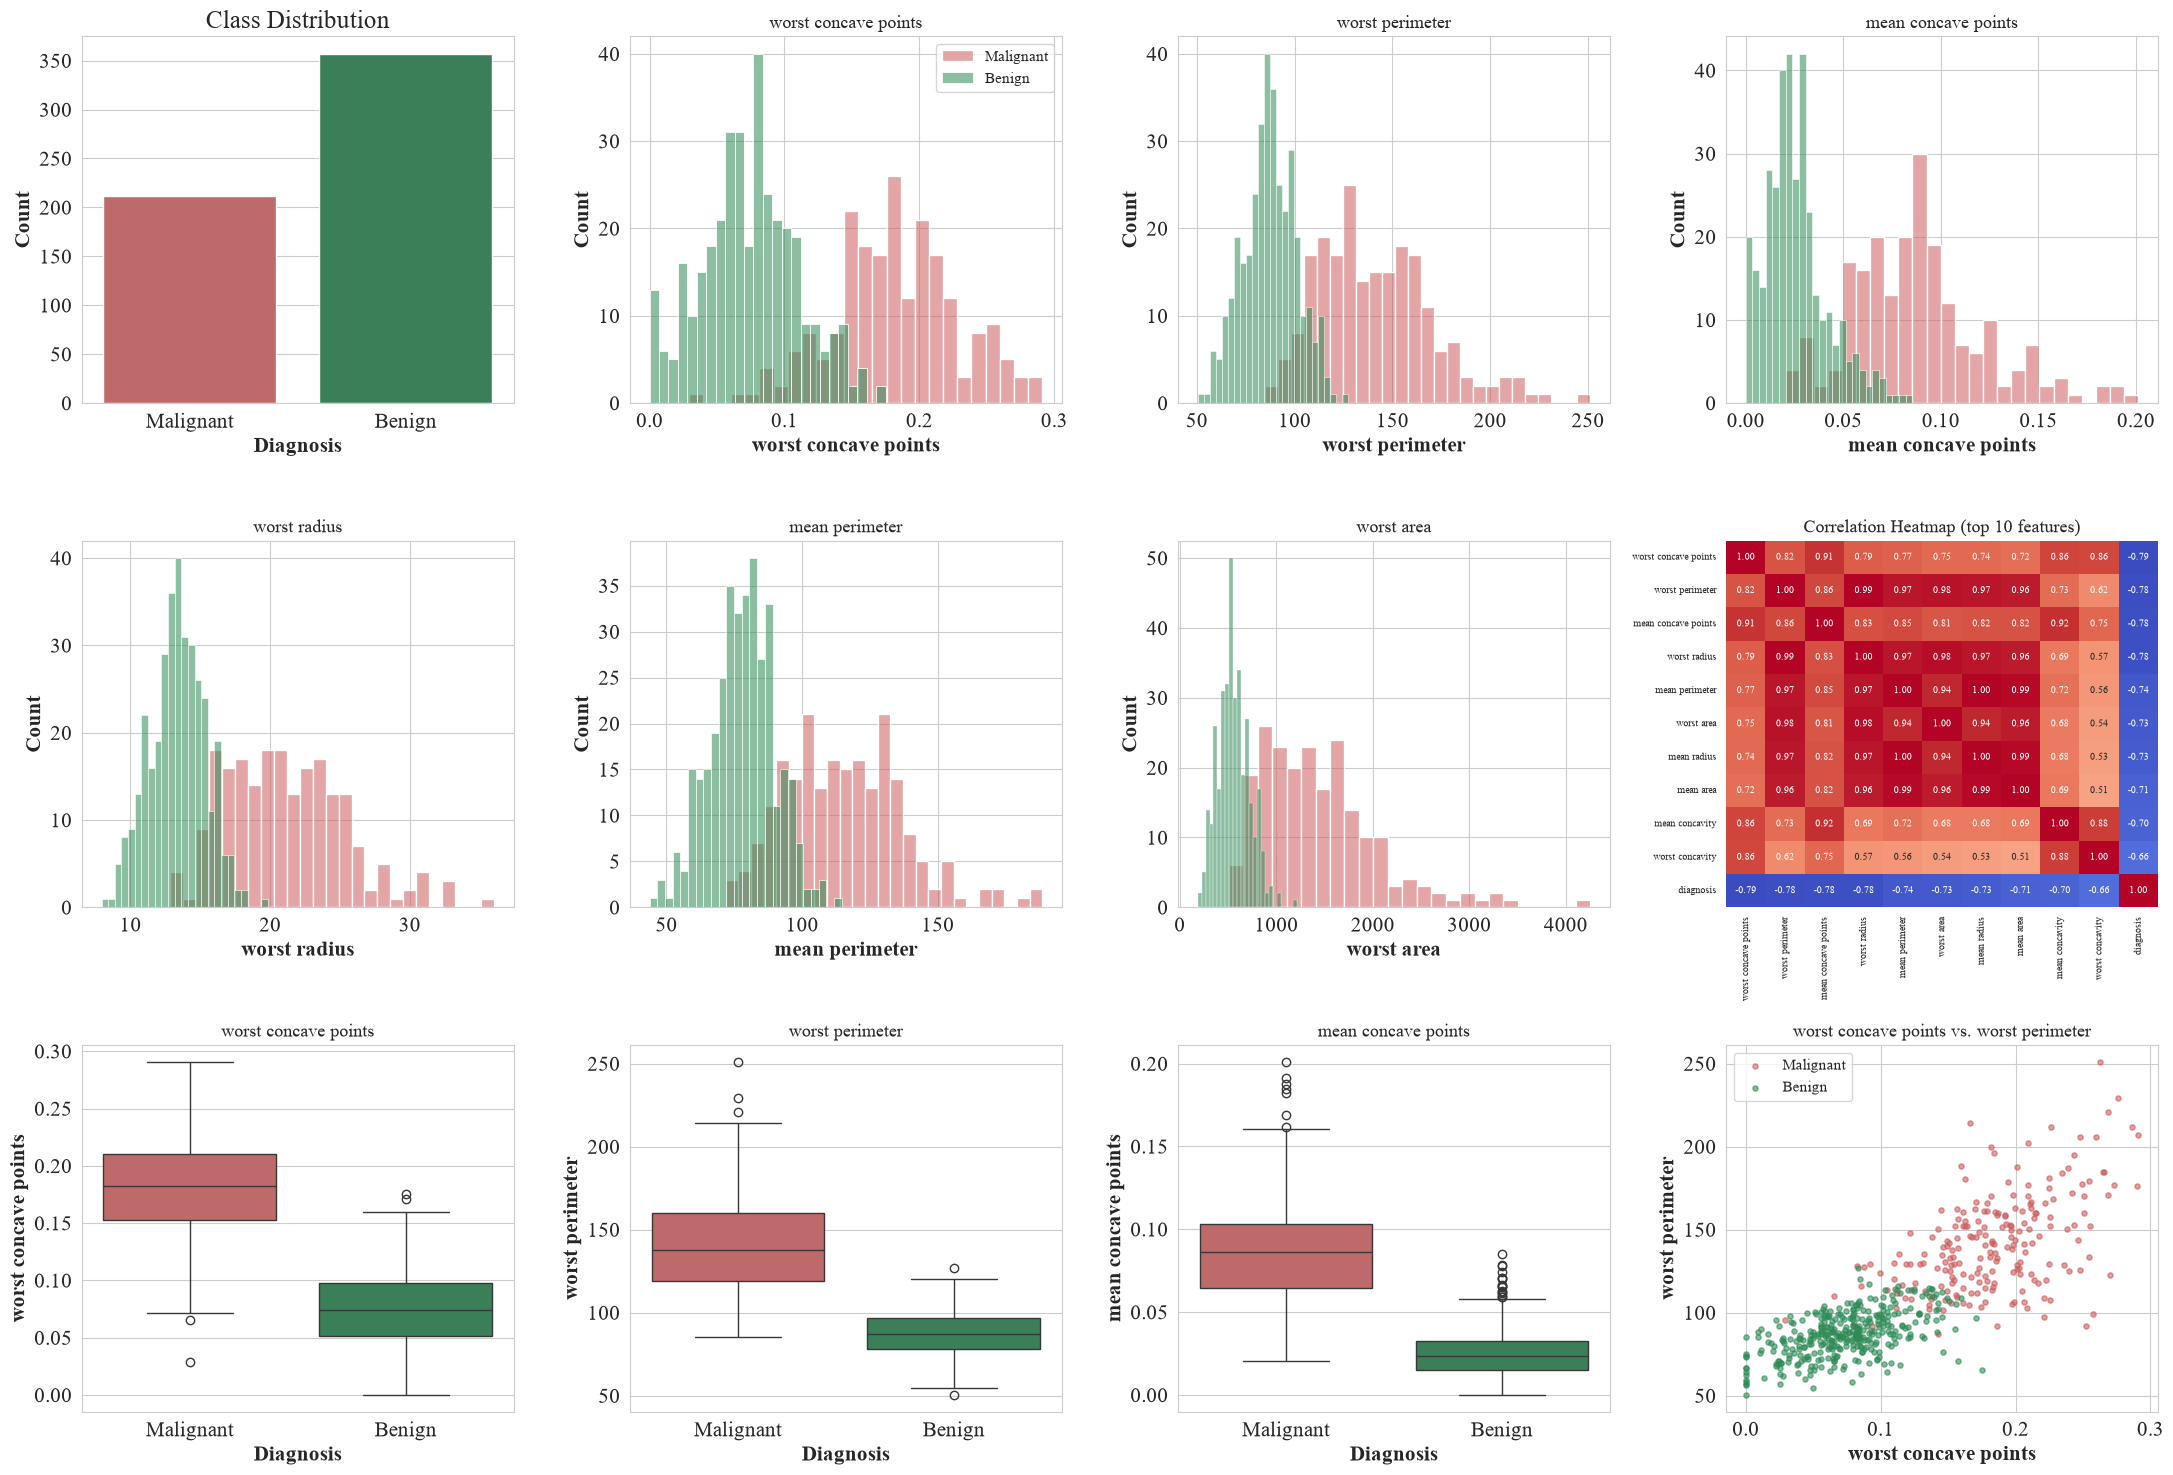


Saved consolidated EDA figure to figures/00_eda_summary.{eps,png}


In [4]:
def build_eda_summary_figure(df, feature_names):
    corr_with_target = df[feature_names + ["diagnosis"]].corr()["diagnosis"].drop("diagnosis").abs().sort_values(ascending=False)
    top_feats = corr_with_target.head(10).index.tolist()

    fig, axes = plt.subplots(3, 4, figsize=(22, 15))
    axes = axes.ravel()

    sns.countplot(x="diagnosis_label", data=df, ax=axes[0], hue="diagnosis_label",
                  palette={"Malignant": "indianred", "Benign": "seagreen"}, legend=False)
    axes[0].set_title("Class Distribution")
    axes[0].set_xlabel("Diagnosis"); axes[0].set_ylabel("Count")

    for i, feat in enumerate(top_feats[:6]):
        ax = axes[1 + i]
        for label, color in [("Malignant", "indianred"), ("Benign", "seagreen")]:
            sns.histplot(df.loc[df["diagnosis_label"] == label, feat], bins=25,
                         color=color, alpha=0.55, label=label, ax=ax, kde=False)
        ax.set_title(feat, fontsize=13)
        ax.set_xlabel(feat); ax.set_ylabel("Count")
        if i == 0:
            ax.legend(fontsize=11)

    ax8 = axes[7]
    heat_cols = top_feats + ["diagnosis"]
    sns.heatmap(df[heat_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
                ax=ax8, cbar=False, annot_kws={"size": 7})
    ax8.set_title("Correlation Heatmap (top 10 features)", fontsize=13)
    ax8.tick_params(axis='x', labelsize=7, rotation=90)
    ax8.tick_params(axis='y', labelsize=7)

    for i, feat in enumerate(top_feats[:3]):
        ax = axes[8 + i]
        sns.boxplot(x="diagnosis_label", y=feat, data=df, ax=ax,
                    hue="diagnosis_label",
                    palette={"Malignant": "indianred", "Benign": "seagreen"}, legend=False)
        ax.set_title(feat, fontsize=13)
        ax.set_xlabel("Diagnosis"); ax.set_ylabel(feat)

    ax12 = axes[11]
    for label, color in [("Malignant", "indianred"), ("Benign", "seagreen")]:
        sub = df[df["diagnosis_label"] == label]
        ax12.scatter(sub[top_feats[0]], sub[top_feats[1]], s=14, alpha=0.6,
                     color=color, label=label)
    ax12.set_xlabel(top_feats[0]); ax12.set_ylabel(top_feats[1])
    ax12.set_title(f"{top_feats[0]} vs. {top_feats[1]}", fontsize=13)
    ax12.legend(fontsize=11)

    plt.tight_layout()
    return fig

eda_fig = build_eda_summary_figure(df, feature_names)
eda_fig.savefig("figures/00_eda_summary.eps", format="eps", dpi=600)
eda_fig.savefig("figures/00_eda_summary.png", dpi=150)
plt.show()
plt.close(eda_fig)
print("\nSaved consolidated EDA figure to figures/00_eda_summary.{eps,png}")

## Train/test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RNG)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

def evaluate(y_true, y_pred, y_score=None):
    d = dict(accuracy=accuracy_score(y_true, y_pred),
             precision=precision_score(y_true, y_pred),
             recall=recall_score(y_true, y_pred),
             f1=f1_score(y_true, y_pred))
    if y_score is not None:
        d["roc_auc"] = roc_auc_score(y_true, y_score)
    return d

def train_and_evaluate_classifier(model, X_train, y_train, X_test, y_test):
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - t0
    t0 = time.perf_counter()
    pred = model.predict(X_test)
    predict_time = time.perf_counter() - t0
    score = model.predict_proba(X_test)[:, 1]
    metrics = evaluate(y_test, pred, score)
    metrics["train_time"] = train_time
    metrics["predict_time"] = predict_time
    return dict(model=model, pred=pred, score=score, metrics=metrics)


Train: (455, 30), Test: (114, 30)


## Baseline decision tree

In [6]:
dt_base = train_and_evaluate_classifier(DecisionTreeClassifier(random_state=RNG),
                                         X_train, y_train, X_test, y_test)
print("\nBaseline Decision Tree:", dt_base["metrics"])


Baseline Decision Tree: {'accuracy': 0.9122807017543859, 'precision': 0.9558823529411765, 'recall': 0.9027777777777778, 'f1': 0.9285714285714286, 'roc_auc': 0.9156746031746031, 'train_time': 0.004038500017486513, 'predict_time': 0.000176099973032251}


## Decision tree tuning

In [7]:
dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=RNG), dt_param_grid,
                        cv=cv5, scoring=["accuracy", "f1"], refit="accuracy", n_jobs=-1)
dt_grid.fit(X_train, y_train)
print("\nDecision Tree GridSearchCV best params:", dt_grid.best_params_)
print("Decision Tree best CV accuracy:", dt_grid.best_score_)

dt_tuned = train_and_evaluate_classifier(dt_grid.best_estimator_, X_train, y_train, X_test, y_test)
print("Tuned Decision Tree (test):", dt_tuned["metrics"])


Decision Tree GridSearchCV best params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Decision Tree best CV accuracy: 0.9384615384615385
Tuned Decision Tree (test): {'accuracy': 0.9035087719298246, 'precision': 0.9420289855072463, 'recall': 0.9027777777777778, 'f1': 0.9219858156028369, 'roc_auc': 0.9358465608465609, 'train_time': 0.002736399997957051, 'predict_time': 0.00017340001068077981}


## Random forest tuning

In [8]:
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 15, None],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False],
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=RNG), rf_param_grid,
                        cv=cv5, scoring=["accuracy", "f1"], refit="accuracy", n_jobs=-1)
rf_grid.fit(X_train, y_train)
print("\nRandom Forest GridSearchCV best params:", rf_grid.best_params_)
print("Random Forest best CV accuracy:", rf_grid.best_score_)

rf_tuned = train_and_evaluate_classifier(rf_grid.best_estimator_, X_train, y_train, X_test, y_test)
print("Tuned Random Forest (test):", rf_tuned["metrics"])


Random Forest GridSearchCV best params: {'bootstrap': True, 'max_depth': 10, 'max_features': 'log2', 'n_estimators': 100}
Random Forest best CV accuracy: 0.964835164835165
Tuned Random Forest (test): {'accuracy': 0.956140350877193, 'precision': 0.958904109589041, 'recall': 0.9722222222222222, 'f1': 0.9655172413793104, 'roc_auc': 0.9923941798941799, 'train_time': 0.06965910000144504, 'predict_time': 0.002810000005410984}


## Hyperparameter sweep tables

In [9]:
best_mss = dt_grid.best_params_["min_samples_split"]
best_msl = dt_grid.best_params_["min_samples_leaf"]
dt_res_full = pd.DataFrame(dt_grid.cv_results_)
dt_sweep = dt_res_full[(dt_res_full["param_min_samples_split"] == best_mss) &
                        (dt_res_full["param_min_samples_leaf"] == best_msl)].copy()
dt_sweep["max_depth_label"] = dt_sweep["param_max_depth"].apply(lambda d: str(d) if d is not None else "None")
dt_sweep = dt_sweep[["param_criterion", "max_depth_label", "mean_test_accuracy", "mean_test_f1"]]
dt_sweep.columns = ["criterion", "max_depth", "avg_cv_accuracy", "avg_cv_f1"]
dt_sweep = dt_sweep.sort_values(["criterion", "max_depth"], key=lambda s: s if s.name == "criterion" else s.map({"3": 0, "5": 1, "7": 2, "10": 3, "None": 4}))
print("\nDecision Tree sweep table (min_samples_split={}, min_samples_leaf={} fixed at best):".format(best_mss, best_msl))
print(dt_sweep.to_string(index=False))

best_mf = rf_grid.best_params_["max_features"]
best_bs = rf_grid.best_params_["bootstrap"]
rf_res_full = pd.DataFrame(rf_grid.cv_results_)
rf_sweep = rf_res_full[(rf_res_full["param_max_features"] == best_mf) &
                        (rf_res_full["param_bootstrap"] == best_bs)].copy()
rf_sweep["max_depth_label"] = rf_sweep["param_max_depth"].apply(lambda d: str(d) if d is not None else "None")
rf_sweep = rf_sweep[["param_n_estimators", "max_depth_label", "param_max_features", "mean_test_accuracy", "mean_test_f1"]]
rf_sweep.columns = ["n_estimators", "max_depth", "max_features", "avg_cv_accuracy", "avg_cv_f1"]
rf_sweep = rf_sweep.sort_values(["n_estimators", "max_depth"], key=lambda s: s if s.name == "n_estimators" else s.map({"5": 0, "10": 1, "15": 2, "None": 3}))
print("\nRandom Forest sweep table (max_features={}, bootstrap={} fixed at best):".format(best_mf, best_bs))
print(rf_sweep.to_string(index=False))


Decision Tree sweep table (min_samples_split=2, min_samples_leaf=4 fixed at best):
criterion max_depth  avg_cv_accuracy  avg_cv_f1
  entropy         3         0.931868   0.946329
  entropy         5         0.925275   0.940394
  entropy         7         0.927473   0.942130
  entropy        10         0.927473   0.942130
  entropy      None         0.927473   0.942130
     gini         3         0.931868   0.945548
     gini         5         0.938462   0.950580
     gini         7         0.934066   0.947040
     gini        10         0.934066   0.947040
     gini      None         0.934066   0.947040

Random Forest sweep table (max_features=log2, bootstrap=True fixed at best):
 n_estimators max_depth max_features  avg_cv_accuracy  avg_cv_f1
           50         5         log2         0.956044   0.965091
           50        10         log2         0.960440   0.968507
           50        15         log2         0.960440   0.968507
           50      None         log2         0.960

## 5-fold CV comparison

In [10]:
dt_cv_scores = cross_val_score(dt_grid.best_estimator_, X_train, y_train, cv=cv5, scoring="accuracy")
rf_cv_scores = cross_val_score(rf_grid.best_estimator_, X_train, y_train, cv=cv5, scoring="accuracy")
print("\nTuned Decision Tree 5-fold CV:", dt_cv_scores, "mean:", dt_cv_scores.mean())
print("Tuned Random Forest 5-fold CV:", rf_cv_scores, "mean:", rf_cv_scores.mean())


Tuned Decision Tree 5-fold CV: [0.94505495 0.94505495 0.91208791 0.92307692 0.96703297] mean: 0.9384615384615385
Tuned Random Forest 5-fold CV: [0.96703297 0.97802198 0.93406593 0.95604396 0.98901099] mean: 0.964835164835165


## Overfitting vs depth

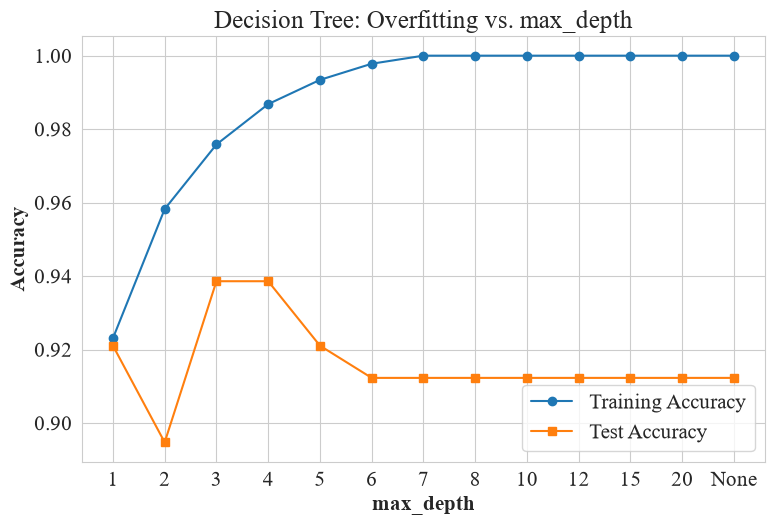

In [11]:
depths = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, None]
train_accs, test_accs = [], []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=RNG).fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))
depth_labels = [str(d) if d is not None else "None" for d in depths]

plt.figure(figsize=(8, 5.5))
plt.plot(depth_labels, train_accs, marker="o", label="Training Accuracy")
plt.plot(depth_labels, test_accs, marker="s", label="Test Accuracy")
plt.xlabel("max_depth"); plt.ylabel("Accuracy")
plt.title("Decision Tree: Overfitting vs. max_depth")
plt.legend(); plt.tight_layout()
plt.savefig("figures/01_dt_depth_overfitting.png", dpi=150); plt.show()
plt.close()

## GridSearch heatmaps

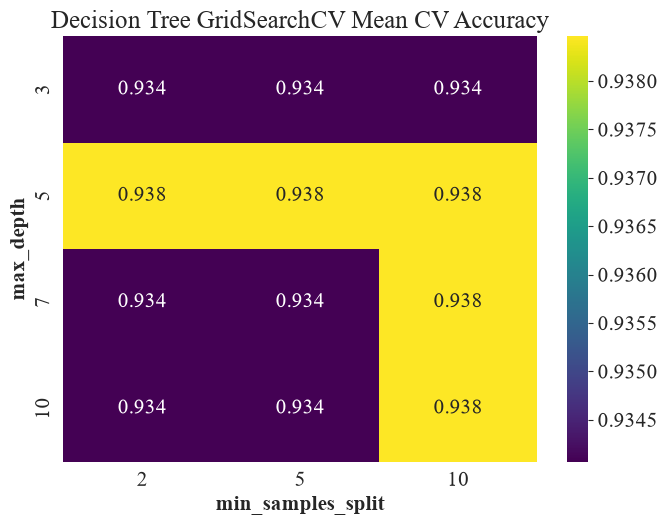

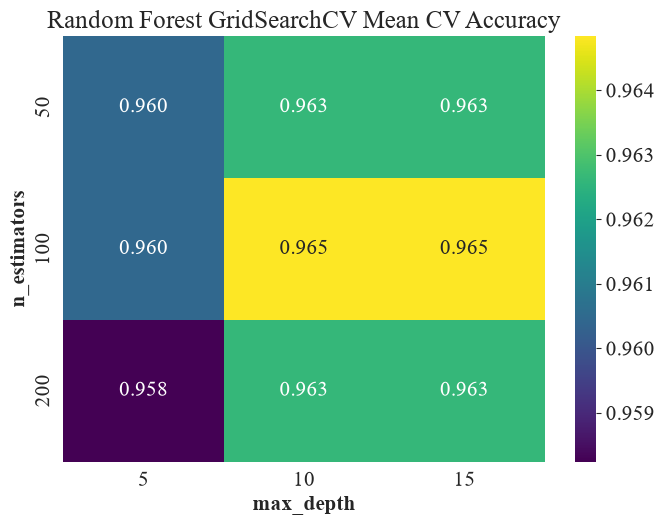

In [12]:
dt_res = pd.DataFrame(dt_grid.cv_results_)
dt_pivot = dt_res.pivot_table(values="mean_test_accuracy",
                               index="param_max_depth", columns="param_min_samples_split",
                               aggfunc="max")
dt_pivot.index = [str(i) for i in dt_pivot.index]
plt.figure(figsize=(7, 5.5))
sns.heatmap(dt_pivot, annot=True, fmt=".3f", cmap="viridis")
plt.xlabel("min_samples_split"); plt.ylabel("max_depth")
plt.title("Decision Tree GridSearchCV Mean CV Accuracy")
plt.tight_layout(); plt.savefig("figures/02_dt_gridsearch_heatmap.png", dpi=150); plt.show()
plt.close()

rf_res = pd.DataFrame(rf_grid.cv_results_)
rf_pivot = rf_res.pivot_table(values="mean_test_accuracy",
                               index="param_n_estimators", columns="param_max_depth",
                               aggfunc="max")
rf_pivot.columns = [str(c) for c in rf_pivot.columns]
plt.figure(figsize=(7, 5.5))
sns.heatmap(rf_pivot, annot=True, fmt=".3f", cmap="viridis")
plt.xlabel("max_depth"); plt.ylabel("n_estimators")
plt.title("Random Forest GridSearchCV Mean CV Accuracy")
plt.tight_layout(); plt.savefig("figures/03_rf_gridsearch_heatmap.png", dpi=150); plt.show()
plt.close()

## Confusion matrices

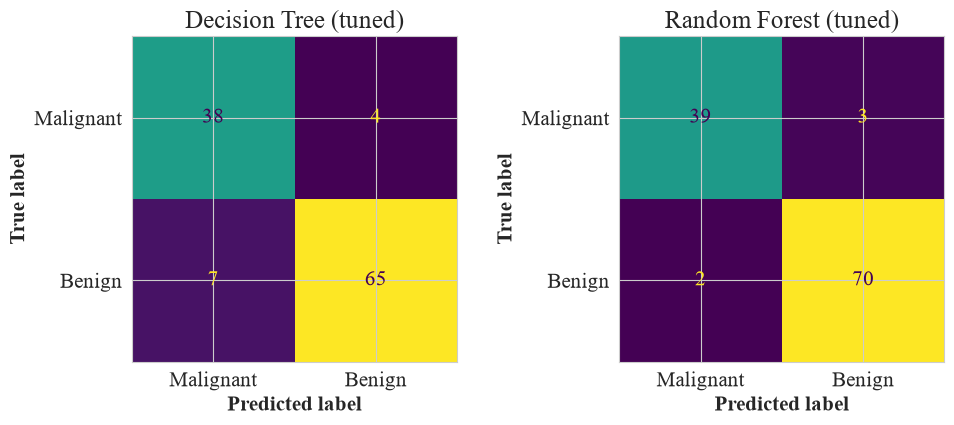

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, dt_tuned["pred"]),
                        display_labels=["Malignant", "Benign"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Decision Tree (tuned)")
ConfusionMatrixDisplay(confusion_matrix(y_test, rf_tuned["pred"]),
                        display_labels=["Malignant", "Benign"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest (tuned)")
plt.tight_layout(); plt.savefig("figures/04_confusion_matrices.png", dpi=150); plt.show()
plt.close()

## ROC curves

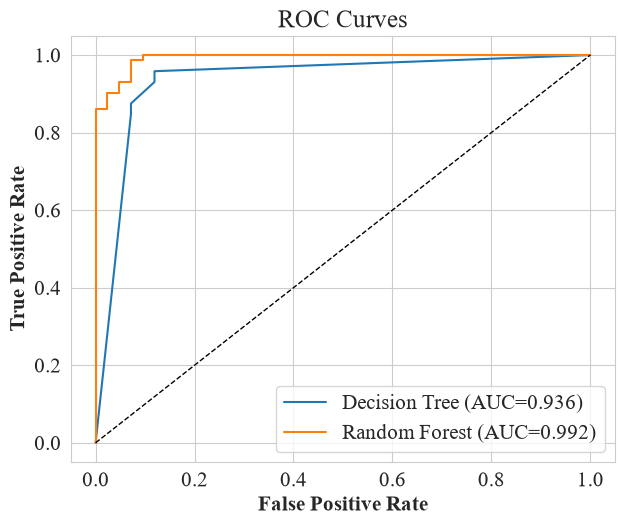

In [14]:
plt.figure(figsize=(6.5, 5.5))
for name, score in [("Decision Tree", dt_tuned["score"]), ("Random Forest", rf_tuned["score"])]:
    fpr, tpr, _ = roc_curve(y_test, score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, score):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves"); plt.legend()
plt.tight_layout(); plt.savefig("figures/05_roc_curves.png", dpi=150); plt.show()
plt.close()

## Feature importance

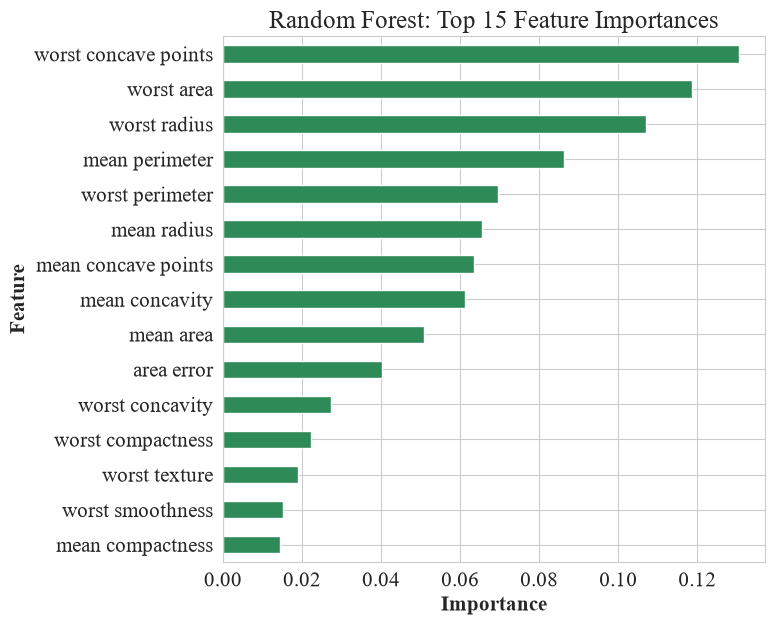

In [15]:
importances = pd.Series(rf_grid.best_estimator_.feature_importances_, index=feature_names)
top_importances = importances.sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 6.5))
top_importances[::-1].plot(kind="barh", color="seagreen")
plt.xlabel("Importance"); plt.ylabel("Feature")
plt.title("Random Forest: Top 15 Feature Importances")
plt.tight_layout(); plt.savefig("figures/06_feature_importance.png", dpi=150); plt.show()
plt.close()

## CV fold comparison

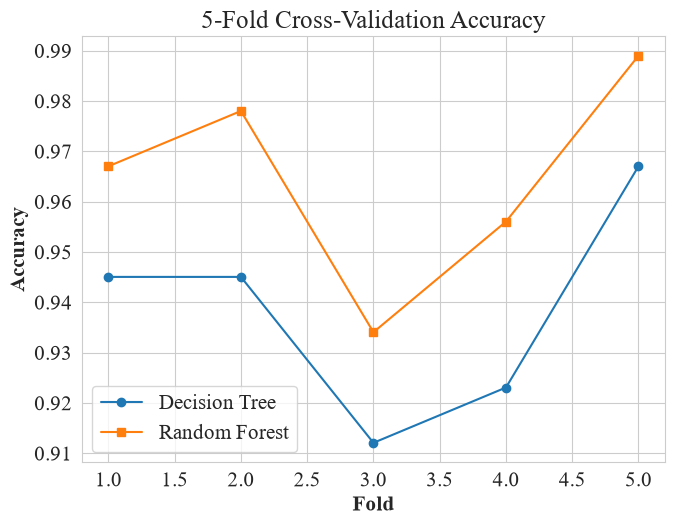

In [16]:
plt.figure(figsize=(7, 5.5))
folds = np.arange(1, 6)
plt.plot(folds, dt_cv_scores, marker="o", label="Decision Tree")
plt.plot(folds, rf_cv_scores, marker="s", label="Random Forest")
plt.xlabel("Fold"); plt.ylabel("Accuracy"); plt.title("5-Fold Cross-Validation Accuracy")
plt.legend(); plt.tight_layout(); plt.savefig("figures/07_cv_fold_comparison.png", dpi=150); plt.show()
plt.close()

## Metric comparison

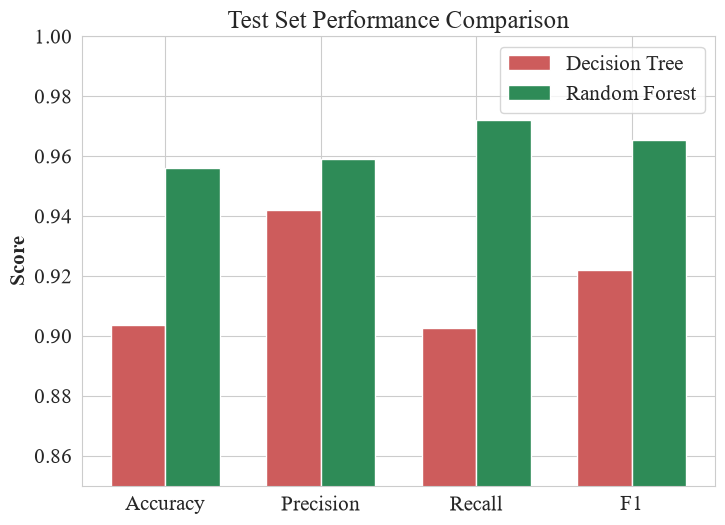

In [17]:
plt.figure(figsize=(7.5, 5.5))
metric_names = ["accuracy", "precision", "recall", "f1"]
dt_vals = [dt_tuned["metrics"][m] for m in metric_names]
rf_vals = [rf_tuned["metrics"][m] for m in metric_names]
x = np.arange(len(metric_names)); w = 0.35
plt.bar(x - w/2, dt_vals, width=w, label="Decision Tree", color="indianred")
plt.bar(x + w/2, rf_vals, width=w, label="Random Forest", color="seagreen")
plt.xticks(x, [m.capitalize() for m in metric_names])
plt.ylim(0.85, 1.0); plt.ylabel("Score")
plt.title("Test Set Performance Comparison"); plt.legend()
plt.tight_layout(); plt.savefig("figures/08_model_comparison.png", dpi=150); plt.show()
plt.close()

## Tree structure

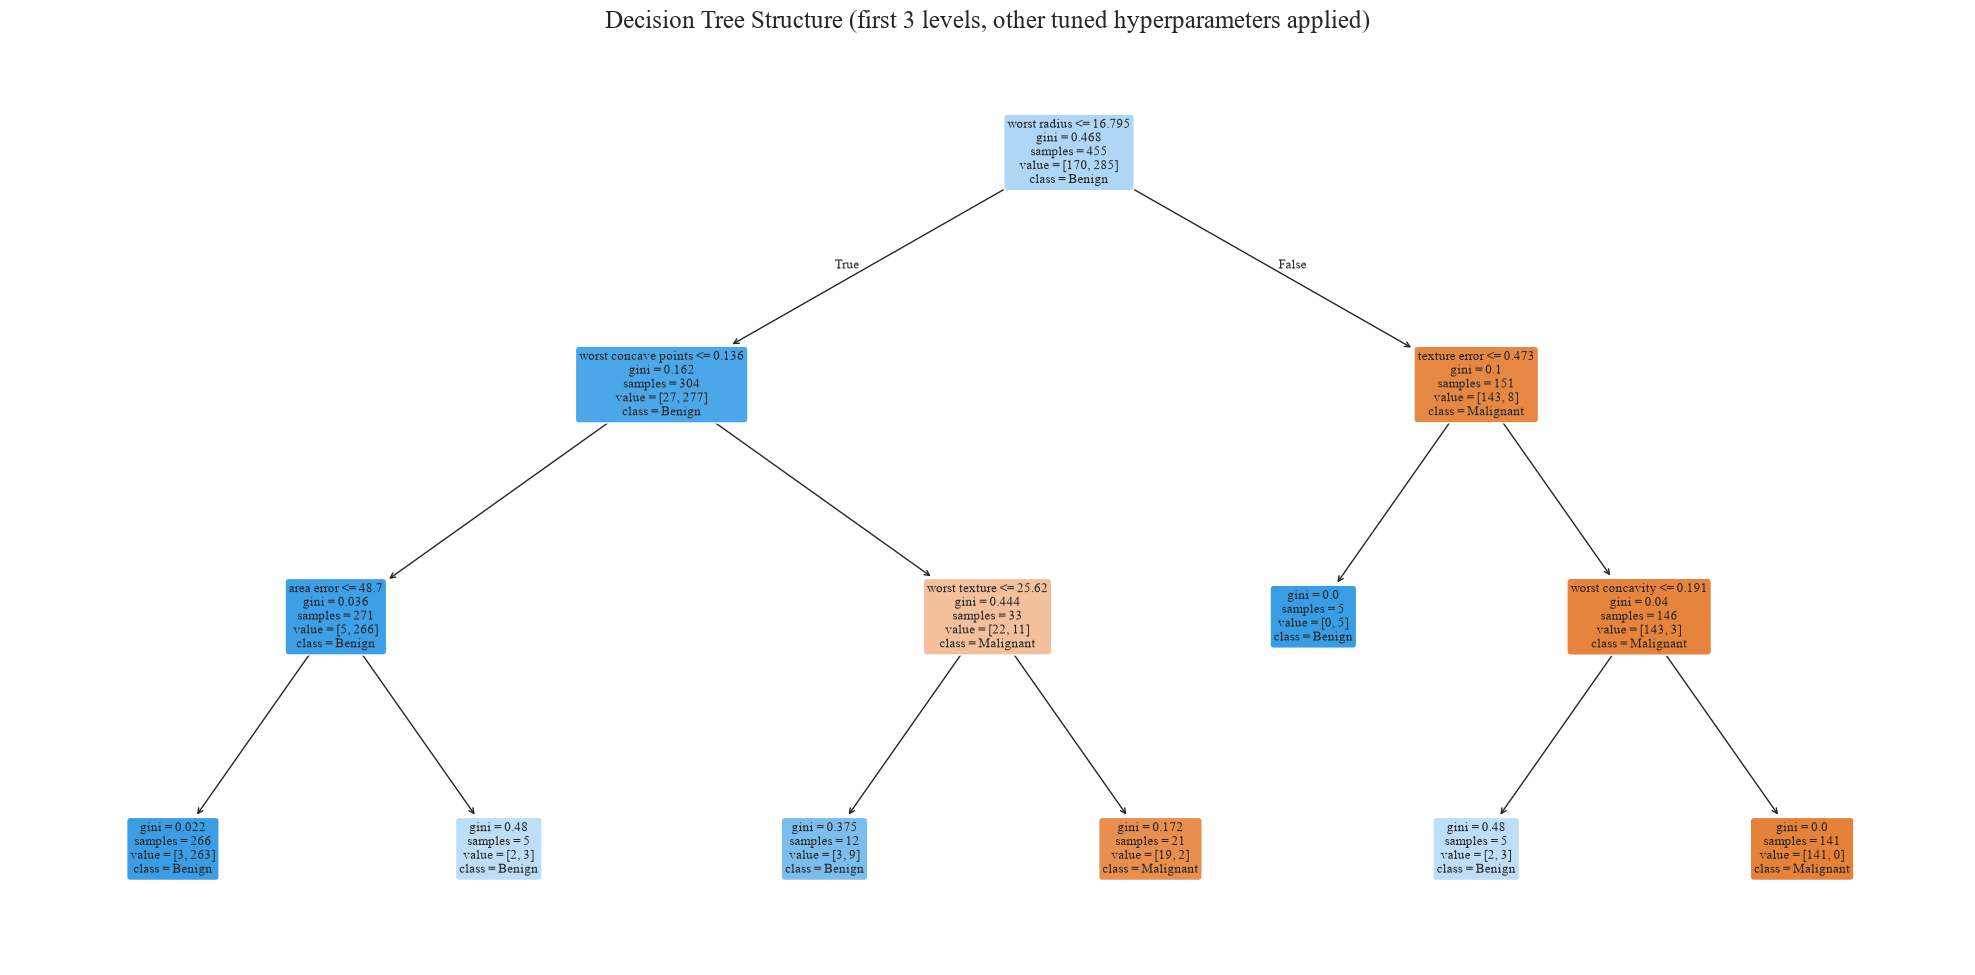

In [18]:
viz_tree = DecisionTreeClassifier(max_depth=3,
                                   **{k: v for k, v in dt_grid.best_params_.items() if k != "max_depth"},
                                   random_state=RNG).fit(X_train, y_train)
plt.figure(figsize=(20, 10))
plot_tree(viz_tree, feature_names=feature_names, class_names=["Malignant", "Benign"],
          filled=True, rounded=True, fontsize=9, max_depth=3)
plt.title("Decision Tree Structure (first 3 levels, other tuned hyperparameters applied)")
plt.tight_layout(); plt.savefig("figures/09_tree_structure.png", dpi=150); plt.show()
plt.close()

## Save results

In [19]:
with open("results_summary.txt", "w") as f:
    f.write(f"Dataset shape: {df.shape}\n")
    f.write(f"Class distribution: {df['diagnosis_label'].value_counts().to_dict()}\n\n")

    f.write(f"Baseline Decision Tree test metrics: {dt_base['metrics']}\n\n")

    f.write(f"Decision Tree GridSearchCV best params: {dt_grid.best_params_}\n")
    f.write(f"Decision Tree GridSearchCV best CV accuracy: {dt_grid.best_score_:.4f}\n")
    f.write(f"Tuned Decision Tree test metrics: {dt_tuned['metrics']}\n\n")

    f.write(f"Random Forest GridSearchCV best params: {rf_grid.best_params_}\n")
    f.write(f"Random Forest GridSearchCV best CV accuracy: {rf_grid.best_score_:.4f}\n")
    f.write(f"Tuned Random Forest test metrics: {rf_tuned['metrics']}\n\n")

    f.write(f"Decision Tree sweep table (min_samples_split={best_mss}, min_samples_leaf={best_msl} fixed):\n")
    f.write(dt_sweep.to_string(index=False) + "\n\n")
    f.write(f"Random Forest sweep table (max_features={best_mf}, bootstrap={best_bs} fixed):\n")
    f.write(rf_sweep.to_string(index=False) + "\n\n")

    f.write(f"Decision Tree 5-fold CV scores: {dt_cv_scores.tolist()}  mean={dt_cv_scores.mean():.4f} std={dt_cv_scores.std():.4f}\n")
    f.write(f"Random Forest 5-fold CV scores: {rf_cv_scores.tolist()}  mean={rf_cv_scores.mean():.4f} std={rf_cv_scores.std():.4f}\n\n")

    f.write("Top 10 Random Forest feature importances:\n")
    f.write(top_importances.head(10).to_string() + "\n\n")

    f.write("Decision Tree overfitting sweep (max_depth -> train_acc, test_acc):\n")
    for d, tr, te in zip(depth_labels, train_accs, test_accs):
        f.write(f"  max_depth={d}: train={tr:.4f}, test={te:.4f}\n")

print("\nDone. Results written to results_summary.txt and figures/ directory.")
print("\n=== FINAL TEST RESULTS ===")
print("Decision Tree (tuned):", dt_tuned["metrics"])
print("Random Forest (tuned):", rf_tuned["metrics"])


Done. Results written to results_summary.txt and figures/ directory.

=== FINAL TEST RESULTS ===
Decision Tree (tuned): {'accuracy': 0.9035087719298246, 'precision': 0.9420289855072463, 'recall': 0.9027777777777778, 'f1': 0.9219858156028369, 'roc_auc': 0.9358465608465609, 'train_time': 0.002736399997957051, 'predict_time': 0.00017340001068077981}
Random Forest (tuned): {'accuracy': 0.956140350877193, 'precision': 0.958904109589041, 'recall': 0.9722222222222222, 'f1': 0.9655172413793104, 'roc_auc': 0.9923941798941799, 'train_time': 0.06965910000144504, 'predict_time': 0.002810000005410984}
